In [1]:
%reload_ext watermark
%watermark -a "Hugo Mendes"

Author: Hugo Mendes



In [2]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# versões dos pacotes
%watermark --iversions

matplotlib: 3.10.7
numpy     : 2.3.5
pandas    : 2.3.3
seaborn   : 0.13.2
sklearn   : 1.8.0



### Rede Neural para regressão

In [4]:
def real_formatter(x, pos):
    return f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

In [5]:
# Carregando o Dataset pré processado
df_limpo = pd.read_csv('Housing_pre_processing.csv')

In [6]:
# Dados de treino e teste
X = df_limpo.drop(columns=['preco'])
y = df_limpo['preco']

In [7]:
# Dividindo os dados
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.20, random_state=42)

In [8]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42) # Criando o Kfold

In [9]:
regressor_target_mlp = TransformedTargetRegressor(
    regressor=MLPRegressor(), # Algoritmo rede neural
    transformer=StandardScaler()
)

In [10]:
pipeline = Pipeline([
    ('scaler', StandardScaler()), # Scaler padronização (valores com média 0 e desvio padrão 1)
    ('mlp', regressor_target_mlp)
])

In [11]:
# Ajuste fino do algoritmo de rede neural
params_mlp = {

    'mlp__regressor__loss': [
        'poisson', 'squared_error' # Função de perda (loss)
    ],
    
    'mlp__regressor__hidden_layer_sizes': [
        (128,) # Quantidade de neuronios na camada oculta
    ],
    
    'mlp__regressor__activation': [
        'relu' # Função de ativação (Aplica não linearidade na rede)
    ],
    
    'mlp__regressor__solver': [
        'adam' # Otimizador (aplica os gradientes calculados para atualizar os pesos)
    ],
    
    'mlp__regressor__alpha': [
        1e-4,
        1e-3,
        1e-2
    ],
    
    'mlp__regressor__learning_rate_init': [
        0.0001,
        0.001,
    ], # Taxa de aprendizado
    
    'mlp__regressor__max_iter': [
        1000,
        2000
    ], # Quantidade de épocas
    
    'mlp__regressor__early_stopping': [
        True
    ],
    
    'mlp__regressor__random_state': [
        42
    ]
}


In [12]:
grid_search_mlp = GridSearchCV(
    pipeline,
    params_mlp,
    cv=kfold,
    n_jobs=-1,
    scoring='r2',
    verbose=1
)

In [13]:
grid_search_mlp.fit(X_treino, y_treino)

Fitting 10 folds for each of 24 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rdScaler()))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__regressor__activation': ['relu'], 'mlp__regressor__alpha': [0.0001, 0.001, ...], 'mlp__regressor__early_stopping': [True], 'mlp__regressor__hidden_layer_sizes': [(128,)], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosit

In [14]:
print(grid_search_mlp.best_params_)
print("-"*100)
print(grid_search_mlp.best_score_)

{'mlp__regressor__activation': 'relu', 'mlp__regressor__alpha': 0.01, 'mlp__regressor__early_stopping': True, 'mlp__regressor__hidden_layer_sizes': (128,), 'mlp__regressor__learning_rate_init': 0.001, 'mlp__regressor__loss': 'squared_error', 'mlp__regressor__max_iter': 1000, 'mlp__regressor__random_state': 42, 'mlp__regressor__solver': 'adam'}
----------------------------------------------------------------------------------------------------
0.6581932530559768


In [15]:
# Salvando o modelo
model_mlp = grid_search_mlp.best_estimator_

In [16]:
y_pred = grid_search_mlp.predict(X_teste)

In [17]:
r2_score = r2_score(y_teste, y_pred)

In [18]:
print(f"Coeficiente de determinação: {r2_score * 100:.2f}%")

Coeficiente de determinação: 66.09%


In [19]:
# Métricas 
mae_mlp = mean_absolute_error(y_teste, y_pred)
rmse_mlp = root_mean_squared_error(y_teste, y_pred)

print(f'MAE: {mae_mlp:.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f'RMSE: {rmse_mlp:.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))

MAE: 950021,63
RMSE: 1288570,61


### Treinando sem os outliers

<Axes: >

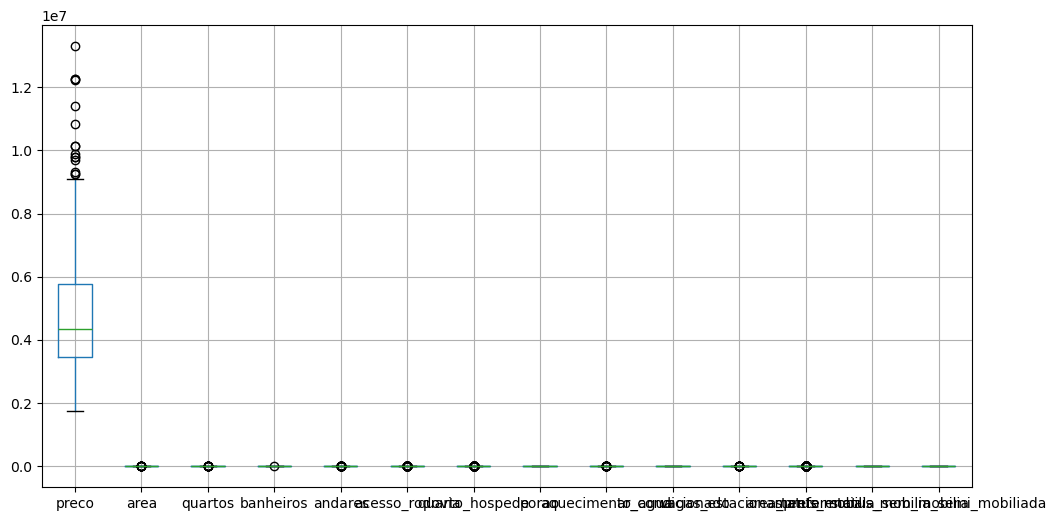

In [20]:
df_limpo.boxplot(figsize=(12,6))

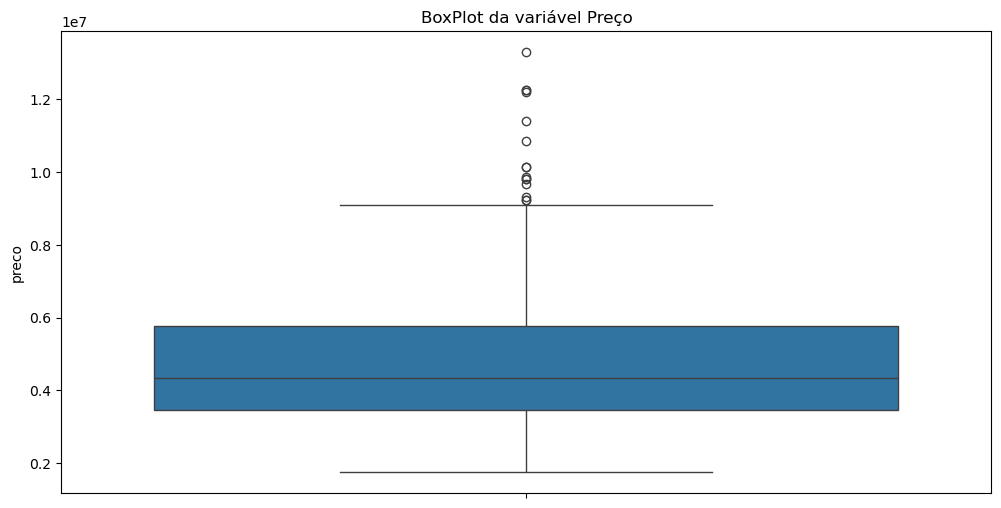

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(df_limpo["preco"])
plt.title("BoxPlot da variável Preço")
plt.show()

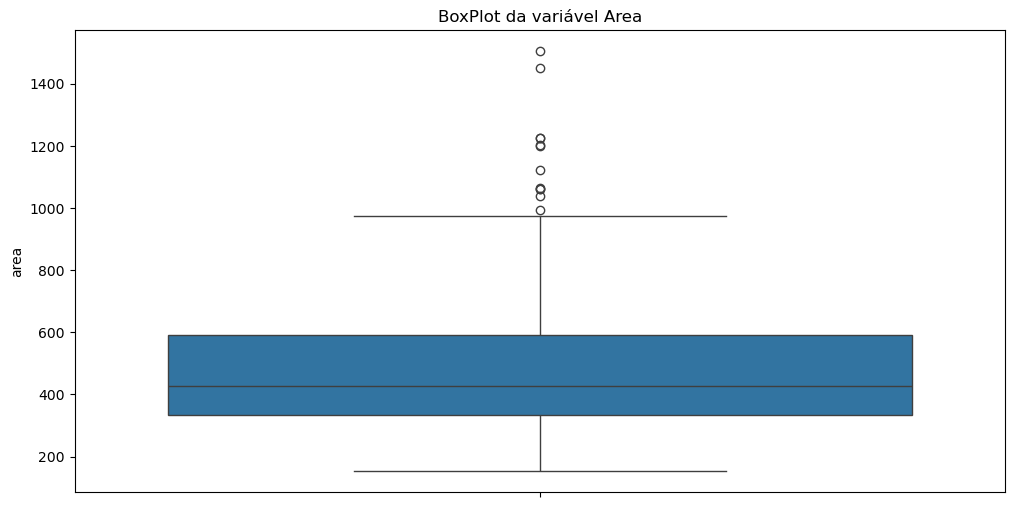

In [22]:
plt.figure(figsize=(12,6))
sns.boxplot(df_limpo["area"])
plt.title("BoxPlot da variável Area")
plt.show()

In [23]:
# Tratanto outliers da variável preço
IC = df_limpo["preco"].quantile(0.75) - df_limpo["preco"].quantile(0.25) # tamanho da caixa do boxplot
formula_preco = df_limpo["preco"].quantile(0.75) + (1.5 * IC) # formula para encontrar valores extremos a partir do ponto máximo

In [24]:
# Visualizando os registros com outliers em preço
outliers_preco = df_limpo[df_limpo["preco"] > formula_preco]
outliers_preco

,preco,area,quartos,banheiros,andares,acesso_rodovia,quarto_hospede,porao,aquecimento_agua,ar_condicionado,vagas_estacionamento,area_preferencial,status_mobilia_sem_mobilia,status_mobilia_semi_mobiliada
0,13300000,689.318,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,832.384,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,925.284,3,2,2,1,0,1,0,0,2,1,0,1
3,12215000,696.750,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,689.318,4,1,2,1,1,1,0,1,2,0,0,0
5,10850000,696.750,3,3,1,1,0,1,0,1,2,1,0,1
6,10150000,797.082,4,3,4,1,0,0,0,1,2,1,0,1
7,10150000,1504.980,5,3,2,1,0,0,0,0,0,0,1,0
8,9870000,752.490,4,1,2,1,1,1,0,1,2,1,0,0
9,9800000,534.175,3,2,4,1,1,0,0,1,1,1,1,0


In [25]:
# Removendo os outliers de preço
df_limpo.drop(index=outliers_preco.index, axis=0, inplace=True)

In [26]:
IC2 = df_limpo["area"].quantile(0.75) - df_limpo["area"].quantile(0.25) # tamanho da caixa do boxplot
formula_area = df_limpo["area"].quantile(0.75) + (1.5 * IC2) # formula para encontrar valores extremos a partir do ponto máximo

In [27]:
outliers_area = df_limpo[df_limpo["area"] > formula_area]
outliers_area

,preco,area,quartos,banheiros,andares,acesso_rodovia,quarto_hospede,porao,aquecimento_agua,ar_condicionado,vagas_estacionamento,area_preferencial,status_mobilia_sem_mobilia,status_mobilia_semi_mobiliada
56,7343000,1062.7760,4,1,2,1,0,1,0,0,1,1,0,1
64,7000000,1038.1575,3,1,1,1,0,1,0,1,1,1,0,0
66,6930000,1226.2800,2,1,1,1,0,1,1,0,1,0,0,0
69,6790000,1123.1610,4,2,2,1,0,0,0,0,2,1,0,0
125,5943000,1449.2400,3,1,1,1,0,0,0,1,2,0,0,1
129,5873000,1064.6340,3,1,3,1,0,0,0,0,2,1,0,1
186,5110000,1059.9890,2,1,2,1,0,0,0,0,0,1,0,0
191,5040000,994.0300,3,1,2,1,1,1,0,0,0,0,0,1
211,4900000,1198.4100,3,1,1,1,0,0,0,0,2,0,0,0
403,3500000,1202.4976,3,1,1,1,0,0,0,0,0,0,1,0


In [28]:
# Removendo os outliers de area
df_limpo.drop(index=outliers_area.index, axis=0, inplace=True)

In [29]:
print(f"Registros após remoção de outliers {df_limpo.shape[0]}")

Registros após remoção de outliers 517


### Treinando após a remoção de outliers

In [30]:
# Dados de treino e teste
X_v2 = df_limpo.drop(columns=['preco'])
y_v2 = df_limpo['preco']

In [31]:
# Dividindo os dados
X_treino_v2, X_teste_v2, y_treino_v2, y_teste_v2 = train_test_split(X_v2, y_v2, test_size=0.20, random_state=42)

In [32]:
grid_search_mlp.fit(X_treino_v2, y_treino_v2)

Fitting 10 folds for each of 24 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rdScaler()))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__regressor__activation': ['relu'], 'mlp__regressor__alpha': [0.0001, 0.001, ...], 'mlp__regressor__early_stopping': [True], 'mlp__regressor__hidden_layer_sizes': [(128,)], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosit

In [33]:
print(grid_search_mlp.best_params_)
print("-"*100)
print(grid_search_mlp.best_score_)

{'mlp__regressor__activation': 'relu', 'mlp__regressor__alpha': 0.01, 'mlp__regressor__early_stopping': True, 'mlp__regressor__hidden_layer_sizes': (128,), 'mlp__regressor__learning_rate_init': 0.0001, 'mlp__regressor__loss': 'squared_error', 'mlp__regressor__max_iter': 1000, 'mlp__regressor__random_state': 42, 'mlp__regressor__solver': 'adam'}
----------------------------------------------------------------------------------------------------
0.5970661059972209


In [34]:
y_pred_v2 = grid_search_mlp.predict(X_teste_v2)

In [35]:
r2_score_v2 = r2_score(y_teste_v2, y_pred_v2)

TypeError: 'float' object is not callable

In [ ]:
print(f"Coeficiente de determinação: {r2_score * 100:.2f}%")